In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("WA_Fn-UseC_-Telco-Customer-Churn.csv")

print(df.shape)
df.head()

(7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [3]:
df.drop("customerID", axis=1, inplace=True)

In [4]:
print(df.shape)
print(df.isnull().sum().sum())
print(df.duplicated().sum())

(7043, 20)
0
22


In [5]:
df["TotalCharges"] = pd.to_numeric(
    df["TotalCharges"],
    errors="coerce"
)

df["TotalCharges"] = df["TotalCharges"].fillna(
    df["TotalCharges"].median()
)

In [6]:
internet_cols = [
    "OnlineSecurity",
    "OnlineBackup",
    "DeviceProtection",
    "TechSupport",
    "StreamingTV",
    "StreamingMovies"
]

for col in internet_cols:
    df[col] = df[col].replace(
        "No internet service",
        "No"
    )

df["MultipleLines"] = df["MultipleLines"].replace(
    "No phone service",
    "No"
)

In [7]:
df.head

<bound method NDFrame.head of       gender  SeniorCitizen Partner Dependents  tenure PhoneService  \
0     Female              0     Yes         No       1           No   
1       Male              0      No         No      34          Yes   
2       Male              0      No         No       2          Yes   
3       Male              0      No         No      45           No   
4     Female              0      No         No       2          Yes   
...      ...            ...     ...        ...     ...          ...   
7038    Male              0     Yes        Yes      24          Yes   
7039  Female              0     Yes        Yes      72          Yes   
7040  Female              0     Yes        Yes      11           No   
7041    Male              1     Yes         No       4          Yes   
7042    Male              0      No         No      66          Yes   

     MultipleLines InternetService OnlineSecurity OnlineBackup  \
0               No             DSL             No  

In [8]:
df = df.drop_duplicates()

In [10]:
df.shape

(7021, 20)

In [11]:
df["Churn"] = df["Churn"].map({
    "No": 0,
    "Yes": 1
})

C:\Users\vansh\AppData\Local\Temp\ipykernel_24180\3695867824.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["Churn"] = df["Churn"].map({


In [12]:
print(df["Churn"].value_counts())
print(df["Churn"].dtype)

Churn
0    5164
1    1857
Name: count, dtype: int64
int64


In [13]:
df = pd.get_dummies(
    df,
    drop_first=True,
    dtype=int
)

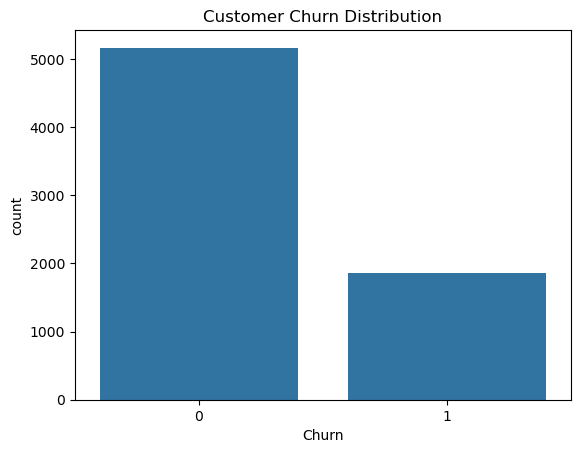

In [15]:
sns.countplot(x="Churn", data=df)
plt.title("Customer Churn Distribution")
plt.show()

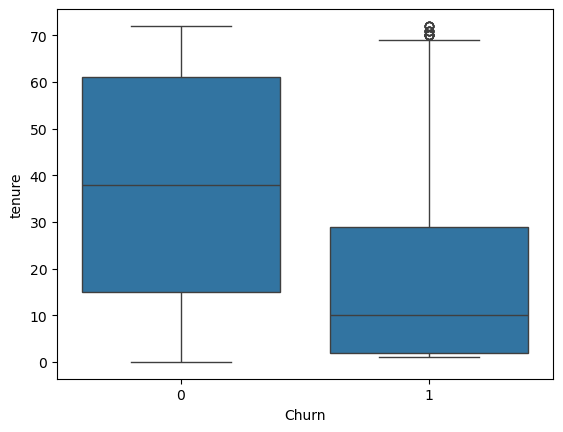

In [17]:
sns.boxplot(
    x="Churn",
    y="tenure",
    data=df
)
plt.show()

In [18]:
from sklearn.model_selection import train_test_split

X = df.drop("Churn", axis=1)
y = df["Churn"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [19]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [24]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(
    max_iter=3000,
    solver="liblinear"
)

model.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'liblinear'
,max_iter,3000
,multi_class,'deprecated'


In [25]:
from sklearn.metrics import *

y_pred = model.predict(X_test)

print("Accuracy:",
      accuracy_score(y_test, y_pred))

print(confusion_matrix(y_test, y_pred))

print(classification_report(
    y_test,
    y_pred
))

Accuracy: 0.802846975088968
[[932 101]
 [176 196]]
              precision    recall  f1-score   support

           0       0.84      0.90      0.87      1033
           1       0.66      0.53      0.59       372

    accuracy                           0.80      1405
   macro avg       0.75      0.71      0.73      1405
weighted avg       0.79      0.80      0.80      1405



In [26]:
from sklearn.metrics import roc_auc_score

y_prob = model.predict_proba(X_test)[:,1]

roc = roc_auc_score(y_test, y_prob)

print("ROC AUC:", roc)

ROC AUC: 0.8401838782541715


In [27]:
importance = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": model.coef_[0]
})

importance = importance.sort_values(
    by="Coefficient",
    ascending=False
)

print(importance.head(10))

                           Feature  Coefficient
3                     TotalCharges     0.637049
9      InternetService_Fiber optic     0.599769
8                MultipleLines_Yes     0.181865
16             StreamingMovies_Yes     0.178137
19            PaperlessBilling_Yes     0.166282
15                 StreamingTV_Yes     0.165735
21  PaymentMethod_Electronic check     0.148741
0                    SeniorCitizen     0.091419
13            DeviceProtection_Yes     0.022105
4                      gender_Male     0.009097


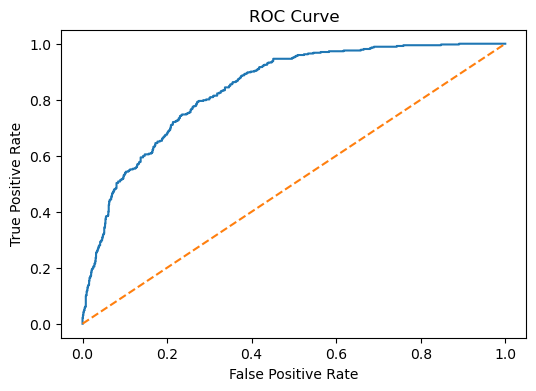

In [28]:
from sklearn.metrics import roc_curve
import matplotlib.pyplot as plt

fpr, tpr, _ = roc_curve(y_test, y_prob)

plt.figure(figsize=(6,4))
plt.plot(fpr, tpr)
plt.plot([0,1],[0,1],'--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.show()

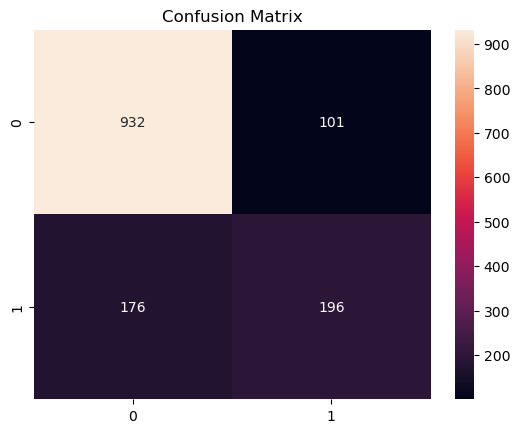

In [29]:
import seaborn as sns

sns.heatmap(
    confusion_matrix(y_test,y_pred),
    annot=True,
    fmt='d'
)

plt.title("Confusion Matrix")
plt.show()